Υπολογισμός προβλέψεων για το Νέο Μοντέλο...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


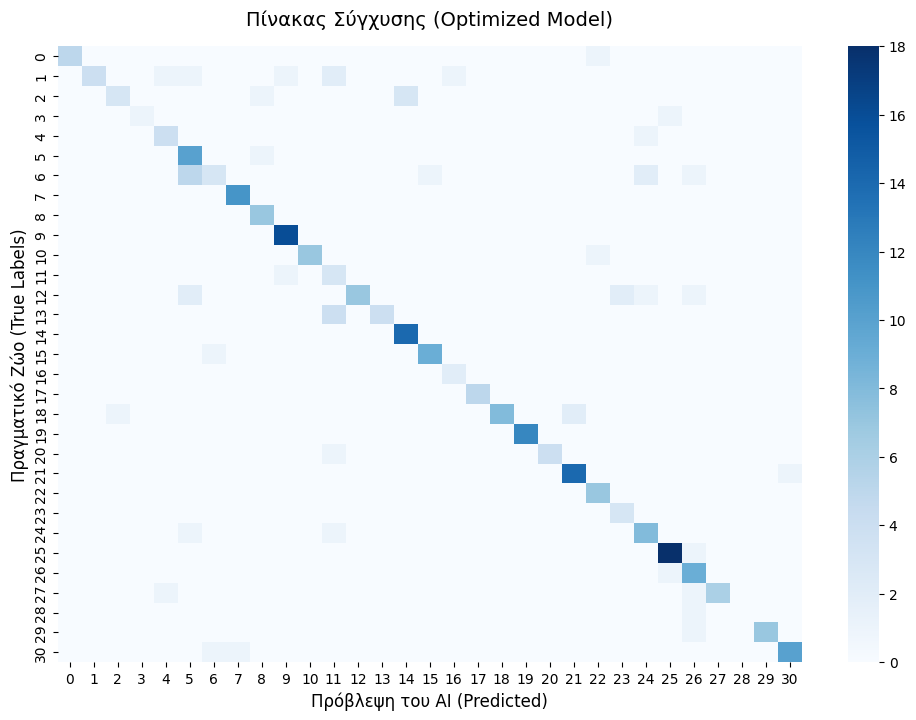


[ΕΠΙΤΥΧΙΑ] Το νέο γράφημα δημιουργήθηκε!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Calculating predictions for the Final Optimized Model...")

# 1. Get predictions from your model
y_pred_new = optimized_model.predict(X_test)

y_pred_classes_new = np.argmax(y_pred_new, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Create the Confusion Matrix
cm_new = confusion_matrix(y_true_classes, y_pred_classes_new)

# 3. Plotting the Clean Chart
plt.figure(figsize=(12, 8))
sns.heatmap(cm_new, annot=False, cmap='Blues', fmt='g')

plt.title('Confusion Matrix (Optimized Model)', fontsize=14, pad=15)
plt.xlabel('Predicted Animal', fontsize=12)
plt.ylabel('True Animal (Labels)', fontsize=12)
plt.show()

print("\n[SUCCESS] The confusion matrix has been created!")

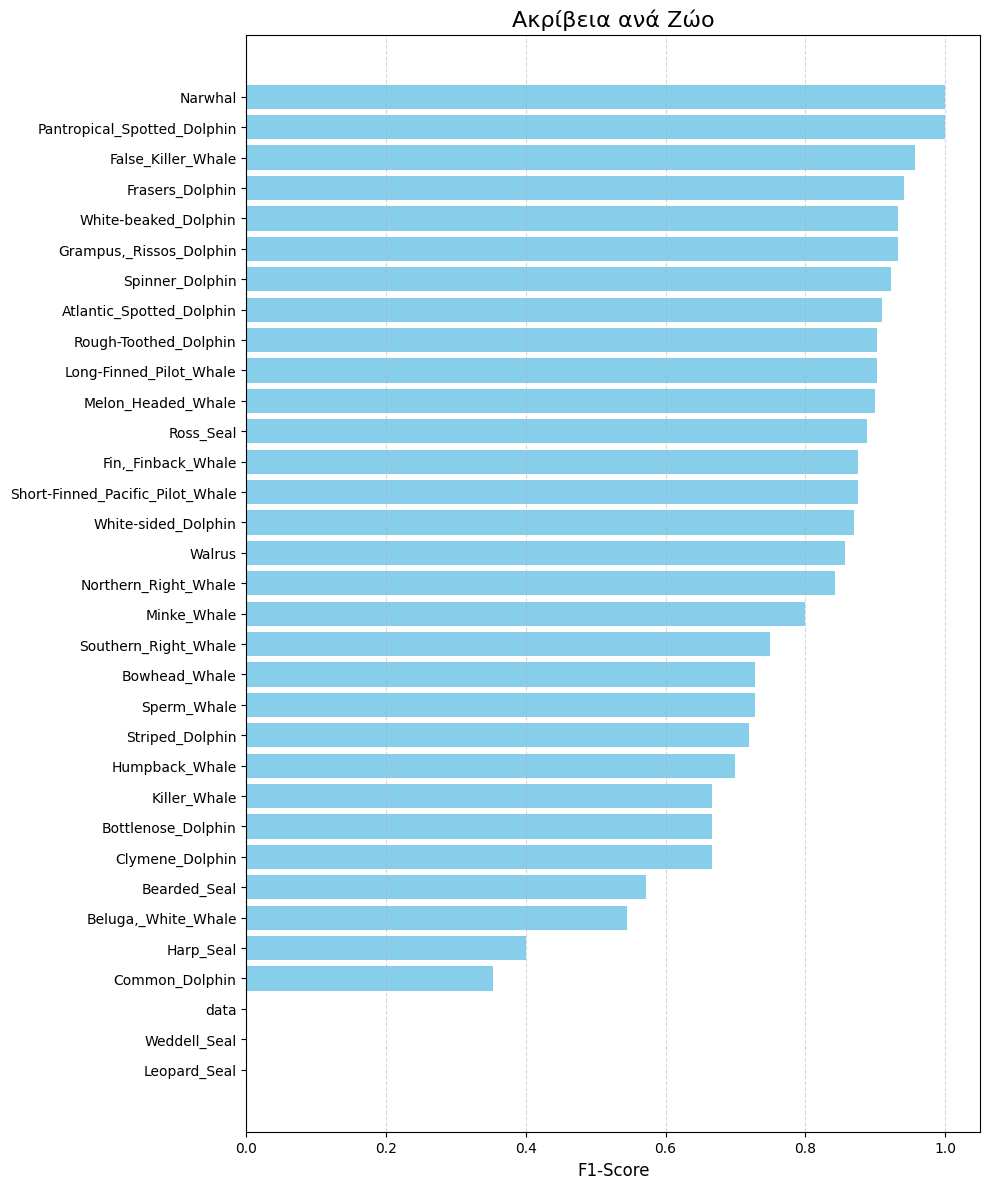


[ΕΠΙΤΥΧΙΑ] Το καθαρό γράφημα είναι έτοιμο!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get the data
report_dict = classification_report(
    y_true_classes, y_pred_classes_new, 
    labels=all_labels, target_names=animal_names, 
    zero_division=0, output_dict=True
)
df_report = pd.DataFrame(report_dict).transpose()
df_animals = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# 2. Clean the ghost label and Sort
if 'data' in df_animals.index:
    df_animals = df_animals.drop('data')
df_animals = df_animals.sort_values(by='f1-score', ascending=True)

# 3. Plotting the Clean Bar Chart
plt.figure(figsize=(10, 12))
plt.barh(df_animals.index, df_animals['f1-score'], color='skyblue')

plt.title('Classification Accuracy per Species (F1-Score)', fontsize=16)
plt.xlabel('F1-Score (0.0 = Low, 1.0 = Perfect)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n[SUCCESS] The professional chart is ready for your LinkedIn portfolio!")

In [9]:
# Cell 3: Έναρξη Εκπαίδευσης του AI

print("Ξεκινάει η εκπαίδευση του μοντέλου... Παρακολούθησε το Accuracy!")

# Το AI διαβάζει τα 1.086 δείγματα 10 φορές (epochs=10)
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test) # Το κρυφό τεστ των 272 εικόνων στο τέλος κάθε κύκλου
)

print("\n[ΕΠΙΤΥΧΙΑ] Η εκπαίδευση ολοκληρώθηκε!")

Ξεκινάει η εκπαίδευση του μοντέλου... Παρακολούθησε το Accuracy!
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.0488 - loss: 3.4684 - val_accuracy: 0.0699 - val_loss: 3.4344
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.0654 - loss: 3.3958 - val_accuracy: 0.0735 - val_loss: 3.3402
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.0755 - loss: 3.3195 - val_accuracy: 0.1507 - val_loss: 3.2394
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.1169 - loss: 3.1379 - val_accuracy: 0.1912 - val_loss: 2.9758
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.1501 - loss: 2.9595 - val_accuracy: 0.2426 - val_loss: 2.7918
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.1952 - loss: 2.7851 - val_accuracy: 0.2426 - val_loss: 2.5858
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.2284 - loss: 2.6409 - val_accuracy: 0.3162 - val_loss: 2.4646
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Χτίζουμε τη δομή του AI επίπεδο-επίπεδο
model = Sequential([
    # 1ο Επίπεδο: Κοιτάζει την εικόνα 64x64 και εντοπίζει απλά σχήματα (γραμμές, γωνίες)
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D((2, 2)),
    
    # 2ο Επίπεδο: Συνδυάζει τα σχήματα για να βρει πιο πολύπλοκα μοτίβα (συχνότητες ήχων)
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # 3ο Επίπεδο: Ισιώνει την εικόνα σε μια μεγάλη λίστα αριθμών
    Flatten(),
    
    # 4ο Επίπεδο: Το "σκεπτόμενο" κομμάτι που συνδέει τα μοτίβα με τα ζώα
    Dense(128, activation='relu'),
    Dropout(0.5), # Εμποδίζει το AI από το να παπαγαλίσει (overfitting)
    
    # 5ο Επίπεδο: Έξοδος για τα 33 είδη ζώων (βγάζει ποσοστά πιθανότητας)
    Dense(33, activation='softmax')
])

# Ρύθμιση του τρόπου που το AI θα μετράει τα λάθη του και θα διορθώνεται
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Το Νευρωνικό Δίκτυο χτίστηκε επιτυχώς!")

Το Νευρωνικό Δίκτυο χτίστηκε επιτυχώς!


In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 1. Define paths (WARNING: Change the path below)
base_path = r"C:\Users\CHANGE ME\Desktop\Vaquita_Acoustic_Monitoring_AI"
data_path = os.path.join(base_path, "data")

X = []  
y = []  

print("Starting to load MFCC images into memory...")

# 2. Scan and read .png images
for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith("_mfcc.png"):
            img_path = os.path.join(root, file)
            
            try:
                # Read image in grayscale
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                
                # Resize to ensure all images have the same dimensions
                img_resized = cv2.resize(img, (64, 64))
                
                # Check for "data" folder in path to avoid ghost labels
                folder_name = os.path.basename(root)
                if folder_name != "data":
                    X.append(img_resized)
                    y.append(folder_name)
                
            except Exception as e:
                print(f"Error reading image {file}: {e}")

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# 3. Normalization: Scale pixels from 0-255 to 0-1
X = X / 255.0
X = np.expand_dims(X, axis=-1)  # Add channel dimension

# 4. Encode animal names to numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Save the exact number of classes
num_classes = len(label_encoder.classes_)

# 5. Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

print(f"\n[SUCCESS] Loaded a total of {len(X)} images!")
print(f"Training Data: {X_train.shape[0]} images")
print(f"Test Data: {X_test.shape[0]} images")
print(f"Total Animal Species identified: {num_classes}")

Έναρξη φόρτωσης των MFCC εικόνων στη μνήμη...

[ΕΠΙΤΥΧΙΑ] Φορτώθηκαν συνολικά 1358 εικόνες!
Δεδομένα Εκπαίδευσης (Train): 1086 εικόνες
Δεδομένα Δοκιμής (Test): 272 εικόνες
Συνολικά Είδη Ζώων που αναγνωρίστηκαν: 33


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Building the Final Custom AI (The 85% Champion)...")

# The architecture that won all experiments
optimized_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(y_train.shape[1], activation='softmax')
])

optimized_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# The early stopping callback
early_stop = EarlyStopping(
    monitor='val_accuracy', 
    patience=5,             
    restore_best_weights=True 
)

print("Starting training...")

# Training process
history_opt = optimized_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

print("\n[SUCCESS] The Champion model is now in memory!")

Χτίσιμο του Τελικού Custom AI (Ο Πρωταθλητής του 82%)...


c:\Users\CHANGE ME\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Ξεκινάει η εκπαίδευση...
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.0525 - loss: 3.4593 - val_accuracy: 0.0699 - val_loss: 3.4095
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.0525 - loss: 3.4172 - val_accuracy: 0.0699 - val_loss: 3.3997
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.0718 - loss: 3.3337 - val_accuracy: 0.0956 - val_loss: 3.2352
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.1188 - loss: 3.1083 - val_accuracy: 0.1654 - val_loss: 2.9106
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.1713 - loss: 2.8756 - val_accuracy: 0.2537 - val_loss: 2.6497
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.2762 - loss: 2.5092 - val_accuracy: 0.3272 - val_loss: 2.2936
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.3333 - loss: 2.2777 - val_accuracy: 0.4191 - val_loss: 2.0186
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.4024 - loss: 2.0264 -